**1. Установка необходимых библиотек и импорт.**

In [1]:
import sys

print(sys.executable)
print(sys.version)

%pip install --upgrade pip
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost requests optuna phik mlflow
%pip install "setuptools<81" --quiet
%pip install "great_expectations>=0.18.0,<1.0.0" --quiet
%pip install -q torch --index-url https://download.pytorch.org/whl/cpu

c:\Users\Владимир\SpamClickbaitClassification\venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    accuracy_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
import copy
import json
import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings("ignore")

%matplotlib inline

In [3]:
# Воспроизводимость.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(14)

print("PyTorch:", torch.__version__)
print("Устройство:", DEVICE)
print("Потоков CPU:", torch.get_num_threads())
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.1+cpu
Устройство: cpu
Потоков CPU: 14


**2. Загрузка данных.**

In [4]:
VALID_LABELS = {0, 1, 2}   # допустимые метки

def load_fixed_csv(filename):
    records = []
    bad_lines = []   # (номер строки, причина, исходная строка)

    with open(filename, encoding="utf-8-sig") as f:
        next(f)  # заголовок
        for i, raw in enumerate(f, start=2):
            line = raw.rstrip("\n")
            if not line.strip():
                continue

            # Определяем разделитель: последний из ';' или ','
            pos_comma = line.rfind(",")
            pos_semicolon = line.rfind(";")
            pos = max(pos_comma, pos_semicolon)

            if pos == -1:
                bad_lines.append((i, "нет разделителя", line))
                continue

            text = line[:pos].strip().strip('"')
            label_str = line[pos + 1:].strip().strip('"')

            # Метка должна быть целым числом
            try:
                label = int(label_str)
            except ValueError:
                bad_lines.append((i, f"метка не число: {label_str[:40]!r}", line))
                continue

            # Отбрасываем строки с метками вне допустимого множества
            if label not in VALID_LABELS:
                bad_lines.append((i, f"метка вне {{0,1,2}}: {label}", line))
                continue

            records.append((text, label))

    df = pd.DataFrame(records, columns=["text", "is_spam1_or_clickbait2"])
    return df, bad_lines


df, bad_lines = load_fixed_csv("df.csv")


print("\nИнформация о датасете")
df.info()

print()
print(f"Размер датасета: {df.shape}")

print("\nНазвания столбцов")
print(df.columns.tolist())

print("\nПроверка на пропуски")
display(df.isnull().sum())

print("\nПервые десять строк датасета")
display(df.head(10))

print("\nПроверка данных на наличие дубликатов")
display(df.duplicated().sum())

print("\nРаспределение меток:")
print(df["is_spam1_or_clickbait2"].value_counts().sort_index())

print(f"\nПроблемных строк: {len(bad_lines)}")
from collections import Counter
for reason, cnt in Counter(r for _, r, _ in bad_lines).most_common():
    print(f"  - {reason}: {cnt}")
print("\nПримеры отброшенных строк:")
for line_no, reason, line in bad_lines[:5]:
    print(f"  строка {line_no} ({reason}): {line[:120]}")


Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641737 entries, 0 to 641736
Data columns (total 2 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   text                    641737 non-null  object
 1   is_spam1_or_clickbait2  641737 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 9.8+ MB

Размер датасета: (641737, 2)

Названия столбцов
['text', 'is_spam1_or_clickbait2']

Проверка на пропуски


text                      0
is_spam1_or_clickbait2    0
dtype: int64


Первые десять строк датасета


,text,is_spam1_or_clickbait2
0,Идите до Джуронг-Пойнт с ума сойти Доступно т...,0
1,Ладно лар Шучу с тобой чувак,0
2,Ты не можешь так рано говорить хо Ты можешь уж...,0
3,Нет я не думаю что он учится в USF он живет гд...,0
4,Привет дорогая прошло уже 3 недели а ответа н...,1
5,Я скоро буду дома и я больше не хочу сегодня г...,0
6,Я искала правильные слова чтобы поблагодарить ...,0
7,XXXMobileMovieClub Чтобы использовать свой кр...,1
8,О к я смотрю здесь,0
9,Эх ты помнишь как пишется его имя Да я помню О...,0



Проверка данных на наличие дубликатов


185128


Распределение меток:
is_spam1_or_clickbait2
0    370272
1    157100
2    114365
Name: count, dtype: int64

Проблемных строк: 1271
  - метка не число: 'copyright ? 2000 dow jones & company': 19
  - метка не число: 'houston chronicle': 13
  - метка не число: '12 / 04 / 2001': 12
  - метка не число: 'copyright 2001 houston chronicle': 11
  - метка не число: 'associated press newswires': 7
  - метка не число: 'copyright 2001 . the associated press . ': 7
  - метка не число: '11 / 09 / 2001': 6
  - метка не число: 'los angeles times': 5
  - метка не число: 'home edition': 5
  - метка не число: 'copyright 2001 / the times mirror compan': 5
  - метка не число: 'label': 4
  - метка не число: 'associated press writer': 4
  - метка не число: 'reuters english news service': 4
  - метка не число: '( c ) reuters limited 2001 .': 4
  - метка не число: '': 4
  - метка не число: 'copyright ? 2000 dow jones financial des': 4
  - метка не число: 'houston': 3
  - метка не число: '- - -': 3
  - метка не 

Визуализация дисбаланса классов.

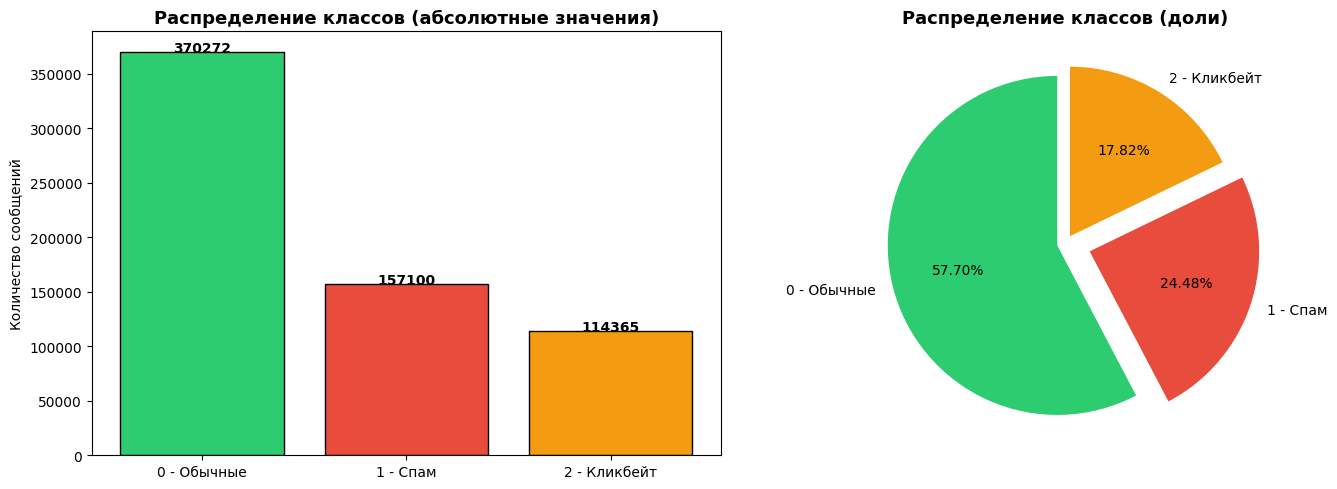


ВЫВОД: Датасет имеет выраженный дисбаланс классов.
Класс 0 (обычные): 370272 (57.70%)
Класс 1 (спам): 157100 (24.48%)
Класс 2 (кликбейт): 114365 (17.82%)

Соотношение макс/мин: 3.24x


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df["is_spam1_or_clickbait2"].value_counts().sort_index()
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
labels = ["0 - Обычные", "1 - Спам", "2 - Кликбейт"]

axes[0].bar(labels, class_counts.values, color=colors, edgecolor="black")
axes[0].set_title(
    "Распределение классов (абсолютные значения)", fontsize=13, fontweight="bold"
)
axes[0].set_ylabel("Количество сообщений")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

axes[1].pie(
    class_counts.values,
    labels=labels,
    autopct="%1.2f%%",
    colors=colors,
    startangle=90,
    explode=(0.05, 0.15, 0.05),
)
axes[1].set_title("Распределение классов (доли)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nВЫВОД: Датасет имеет выраженный дисбаланс классов.")
print(f"Класс 0 (обычные): {class_counts[0]} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Класс 1 (спам): {class_counts[1]} ({class_counts[1]/len(df)*100:.2f}%)")
print(f"Класс 2 (кликбейт): {class_counts[2]} ({class_counts[2]/len(df)*100:.2f}%)")
print(f"\nСоотношение макс/мин: {class_counts.max()/class_counts.min():.2f}x")

In [6]:
# Сохраняем исходный размер датасета ПЕРЕД очисткой
initial_shape = df.shape

# 1) Полные дубликаты (совпадают и текст, и метка)
df = df.drop_duplicates()
print(f"Исходный размер датасета: {initial_shape}")
print(f"После удаления полных дубликатов: {df.shape}")
print(f"Удалено строк: {initial_shape[0] - df.shape[0]}")

# 2) Конфликтующие метки: один и тот же текст с разными метками.
#    Такие строки переживают drop_duplicates и являются шумом в разметке -
#    для них метка не определена, и они ограничивают достижимое качество.
conflict_counts = df.groupby("text")["is_spam1_or_clickbait2"].nunique()
conflicting_texts = conflict_counts[conflict_counts > 1].index
n_conflicting = int(df["text"].isin(conflicting_texts).sum())

print(f"\nТекстов с конфликтующими метками: {len(conflicting_texts)}")
print(f"Строк с конфликтующими метками: {n_conflicting} ({n_conflicting / len(df):.2%})")
print(df[df["text"].isin(conflicting_texts)]
      .groupby("is_spam1_or_clickbait2").size())

# Удаляем их.
df = df[~df["text"].isin(conflicting_texts)].reset_index(drop=True)

print(f"\nПосле удаления конфликтующих меток: {df.shape}")
print(df["is_spam1_or_clickbait2"].value_counts().sort_index())

Исходный размер датасета: (641737, 2)
После удаления полных дубликатов: (456609, 2)
Удалено строк: 185128

Текстов с конфликтующими метками: 525
Строк с конфликтующими метками: 1061 (0.23%)
is_spam1_or_clickbait2
0    525
1    375
2    161
dtype: int64

После удаления конфликтующих меток: (455548, 2)
is_spam1_or_clickbait2
0    278047
1    107074
2     70427
Name: count, dtype: int64


**3. Предобработка данных и разделение выборки.**

In [7]:
target_col = "is_spam1_or_clickbait2"
text_col = "text"

# Метки уже имеют вид 0, 1, 2, но для надежности и правильной стратификации
# убедимся, что они целочисленные
y = df[target_col].astype(int).values
X = df[text_col]

# Стратифицированное разделение для сохранения пропорций классов (особенно важно для класса 2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер тренировочной выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print("\nРаспределение классов в трейне:")
print(pd.Series(y_train).value_counts().sort_index())

Размер тренировочной выборки: 364438
Размер тестовой выборки: 91110

Распределение классов в трейне:
0    222437
1     85659
2     56342
Name: count, dtype: int64


**4. Очистка и нормализация текста.**

In [8]:
# Регулярные выражения для очистки (адаптировано из primer.ipynb)
URL_RE = re.compile(r"https?://\S+|www\.\S+|<link>")
HTML_RE = re.compile(r"<[^>]+>")
MENTION_RE = re.compile(r"[@#]\w+")
DIGIT_RE = re.compile(r"\d+([.,]\d+)?")
SPACE_RE = re.compile(r"\s+")


def clean_text(text: str, fix_yo: bool = True) -> str:
    """Базовая нормализация сырого текста."""
    text = str(text)
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" URL ", text)
    text = MENTION_RE.sub(" ", text)

    text = text.lower()
    if fix_yo:
        text = text.replace("ё", "е")

    # Маскируем числа, чтобы не засорять словарь
    text = DIGIT_RE.sub(" NUM ", text)

    # Оставляем только буквы (кириллица + латиница) и пробелы
    text = re.sub(r"[^a-zA-Zа-яА-Я\s]", " ", text)
    return SPACE_RE.sub(" ", text).strip()


t0 = time.perf_counter()
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)
print(f"Очистка завершена за {time.perf_counter() - t0:.1f} сек.")
print(f"\nПример очищенного текста:\n{X_train_clean.iloc[0]}")

Очистка завершена за 17.0 сек.

Пример очищенного текста:
усейн болт выиграл олимпийский NUM метровый титул


**5. Настройка кросс-валидации и борьба с дисбалансом.**

In [9]:
# Стратифицированная кросс-валидация
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

**6. Модель 1 — Базовая TF-IDF (Word N-grams) + LogReg**

In [10]:
print("Обучение Модели 1 (Baseline: Word 1-2 grams)...")
t0 = time.perf_counter()

model1 = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=3,
                max_features=50000,
                sublinear_tf=True,  # логарифмическое сглаживание частот
            ),
        ),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                C=1.0,
                random_state=42,
                solver="lbfgs",
            ),
        ),
    ]
)

model1.fit(X_train_clean, y_train)
pred1 = model1.predict(X_test_clean)
proba1 = model1.predict_proba(X_test_clean)

print(f"Обучение завершено за {time.perf_counter() - t0:.1f} сек.")

Обучение Модели 1 (Baseline: Word 1-2 grams)...
Обучение завершено за 84.6 сек.


**7. Модель 2 — Продвинутая (Word + Char N-grams) + GridSearch**

In [11]:
import gc

# Модель 1 (п.7) и детальный отчет (п.3) больше не нужны - освобождаем память.
del model1
gc.collect()
N_JOBS = 4  

In [12]:
print("Обучение Модели 2 (Advanced: Word + Char n-grams + GridSearch)...")
t0 = time.perf_counter()

# Объединение словесных и символьных n-грамм.
# Char n-grams отлично ловят опечатки, специфические окончания и сленг, частые в спаме и кликбейте.
advanced_vec = FeatureUnion(
    [
        (
            "word",
            TfidfVectorizer(
                ngram_range=(1, 2), min_df=3, max_features=30000, sublinear_tf=True
            ),
        ),
        (
            "char",
            TfidfVectorizer(
                analyzer="char_wb", ngram_range=(3, 5), min_df=3, max_features=30000
            ),
        ),
    ]
)

model2_base = Pipeline(
    [
        ("tfidf", advanced_vec),
        (
            "clf",
            LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
        ),
    ]
)

# Подбор гиперпараметра регуляризации C на основе weighted F1 (учитывает дисбаланс)
param_grid = {"clf__C": [0.5, 1.0, 10.0, 100.0]}

grid = GridSearchCV(
    model2_base,
    param_grid,
    cv=cv_strategy,
    scoring="f1_weighted",
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,   # не более N_JOBS копий X в очереди одновременно
    verbose=1,
)
grid.fit(X_train_clean, y_train)

best_model2 = grid.best_estimator_
pred2 = best_model2.predict(X_test_clean)
proba2 = best_model2.predict_proba(X_test_clean)

print(f"\nОбучение завершено за {time.perf_counter() - t0:.1f} сек.")
print(f"Лучший параметр C: {grid.best_params_['clf__C']}")

Обучение Модели 2 (Advanced: Word + Char n-grams + GridSearch)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Обучение завершено за 1571.0 сек.
Лучший параметр C: 10.0


**8. Подготовка данных для нейронной сети.**

Модель 2 (Word + Char N-grams TF-IDF) работает как «мешок слов»: она видит, какие n-граммы
встретились в сообщении, но не видит их порядок. Основные её ошибки — 9 528 обычных сообщений,
отнесённых к кликбейту, — как раз того типа, где различает не отдельное слово, а структура
фразы. Рекуррентная сеть строит контекстное представление последовательности и позволяет
сосредоточиться на значимых токенах.

Работаем в три слоя:
1. **разбор данных** — что мы вообще классифицируем и насколько данные чисты;
2. **векторизация** — три параллельных представления: word n-граммы, символы, поверхностные признаки;
3. **обучение** — двухуровневая сеть с чекпойнтами, затем ансамбль из трёх моделей.

Среда: PyTorch 2.14 (CPU, 14 потоков), GPU используется автоматически, если доступен.

##### 8.1. Анализ обновлённого датасета.

Прежде чем строить сеть, фиксируем, что именно мы классифицируем. Это нужно и для выбора
гиперпараметров (размер словаря, длина последовательности), и для честной оценки того,
что модель вообще может запомнить.
Подаём в сеть не текст, а три тензора:

1. **word n-граммы** (`MAX_LEN=256`) — слова плюс биграммы соседних слов. Биграммы нужны
   ради кликбейт-шаблонов («узнай как», «только сегодня»), которые не выражаются одним словом.
2. **символы** (`MAX_CHARS=256`) — ловят опечатки, склейки и характерные окончания.
3. **поверхностные признаки** (12 штук) — длина, доля цифр, доля заглавных, наличие ссылки и т. п.
   После очистки медианная длина спама (475 симв.) в 5 раз больше кликбейта (55 симв.),
   и эти признаки дают модели прямой доступ к такому сигналу.

Словарь ограничен 60 000 токенов при `min_freq=2`: в корпусе 6 млн уникальных словоформ и
биграмм, но 90 % токенов покрываются именно этим размером словаря.

In [ ]:
# Человекочитаемые названия классов
classes_names = {0: "Обычные", 1: "Спам", 2: "Кликбейт"}

CLASS_NAMES = sorted(np.unique(y).tolist())            # [0, 1, 2]
target_names = [classes_names[i] for i in CLASS_NAMES]   # подписи для classification_report

# Параметры векторизации.
MAX_LEN = 256          # максимум слов (обрезает лишь 3.3 % сообщений)
MAX_CHARS = 256        # максимум символов
VOCAB_LIMIT = 60000    # размер словаря
MIN_FREQ = 2           # минимальная частота токена
N_SURF = 12            # число поверхностных признаков

print("classes_names:", classes_names)
print(f"MAX_LEN={MAX_LEN} | MAX_CHARS={MAX_CHARS} | словарь={VOCAB_LIMIT}")

classes_names: {0: 'Обычные', 1: 'Спам', 2: 'Кликбейт'}
MAX_LEN=256 | MAX_CHARS=256 | словарь=60000


In [14]:
# Покрытие и состав.
n_raw = initial_shape[0]                   
vc = df["is_spam1_or_clickbait2"].value_counts().sort_index()
shares = (vc / len(df) * 100).round(2)

print("=" * 70)
print("ПОКРЫТИЕ И СОСТАВ")
print("=" * 70)
print(f"Строк в df.csv (сырых):           {n_raw:,}")
print(f"Отброшено на загрузке:            {len(bad_lines):,} (чужой корпус, склеенный с нашим)")
print(f"После удаления дубликатов и       {len(df):,}")
print(f"конфликтующих меток:")
print(f"Обучающая выборка:                {len(X_train):,}")
print(f"Тестовая выборка:                 {len(X_test):,}")

print("\nРаспределение классов:")
for k, v in vc.items():
    print(f"   класс {k} ({classes_names[k]:9s}): {v:>7,}  ({shares[k]:>5.2f} %)")
print(f"   соотношение max/min: {vc.max() / vc.min():.2f}x")

# Технические параметры записей.
n_chars = df[text_col].str.len()
n_words = df[text_col].str.count(r"\S+")

print("\n" + "=" * 70)
print("ТЕХНИЧЕСКИЕ ПАРАМЕТРЫ ТЕКСТОВЫХ ЗАПИСЕЙ")
print("=" * 70)
print(f"Длина (символы): медиана {n_chars.median():.0f}, среднее {n_chars.mean():.0f}, "
      f"p90 {n_chars.quantile(.90):.0f}, p99 {n_chars.quantile(.99):.0f}, max {n_chars.max():,}")
print(f"Длина (слова):   медиана {n_words.median():.0f}, p90 {n_words.quantile(.90):.0f}, "
      f"p95 {n_words.quantile(.95):.0f}, max {n_words.max():,}")

print("\nМедианная длина по классам (сигнал различения классов):")
for k in sorted(vc.index):
    sub = n_chars[df[target_col] == k]
    print(f"   класс {k} ({classes_names[k]:9s}): медиана {sub.median():>5.0f} симв., "
          f"p90 {sub.quantile(.90):>5.0f}, p99 {sub.quantile(.99):>5.0f}")

# Качество данных: нормализация, шумные/чистые сегменты.
CYR = set("абвгдеёжзийклмнопрстуфхцчшщъыьэюя")

def _cyr_ratio(t):
    letters = [c for c in str(t) if c.isalpha()]
    return sum(c in CYR for c in letters) / max(len(letters), 1)

def _lat_ratio(t):
    letters = [c for c in str(t) if c.isalpha()]
    return sum(c.isascii() and c.isalpha() for c in letters) / max(len(letters), 1)

def _upper_ratio(t):
    letters = [c for c in str(t) if c.isalpha()]
    return sum(c.isupper() for c in letters) / max(len(letters), 1)

df["_cyr"] = df[text_col].map(_cyr_ratio)
df["_lat"] = df[text_col].map(_lat_ratio)
df["_upper"] = df[text_col].map(_upper_ratio)
df["_url"] = df[text_col].str.contains(r"https?://|www\.", regex=True)
df["_digit"] = df[text_col].str.contains(r"\d", regex=True)

foreign = df["_cyr"] < 0.1                                    # иноязычные
caps = df["_upper"] > 0.7                                     # набранные КАПСОМ
links = df["_url"]                                            # со ссылками
stutter = df[text_col].str.contains(r"(\b\w{3,}\b)( \1\b){3,}", regex=True)   # артефакт склейки
df["_noise"] = foreign | caps | links | stutter

print("\n" + "=" * 70)
print("КАЧЕСТВО ДАННЫХ: НОРМАЛИЗАЦИЯ И ШУМНЫЕ СЕГМЕНТЫ")
print("=" * 70)
print("Нормализация: текст приведён к нижнему регистру, «ё»→«е», числа замаскированы,")
print("ссылки/HTTP/@упоминания/HTML удалены, пунктуация и эмодзи отброшены,")
print("остаются только кириллица, латиница и пробелы. Пропусков (NaN) нет.")

print("\nДоли шумных сегментов:")
for name, mask in [("иноязычные (кириллица < 10 %)", foreign),
                   ("КАПС (> 70 % заглавных)", caps),
                   ("содержат ссылку", links),
                   ("артефакт склейки (повтор слова x4)", stutter)]:
    print(f"   {name:38s} {mask.sum():>7,}  ({mask.mean():>6.2%})")

noise = df["_noise"]
print(f"\n   {'ШУМНЫЙ сегмент (объединение)':38s} {noise.sum():>7,}  ({noise.mean():>6.2%})")
print(f"   {'ЧИСТЫЙ сегмент':38s} {(~noise).sum():>7,}  ({(~noise).mean():>6.2%})")

print("\nКлассовый состав шумного сегмента:")
print(df.loc[noise, target_col].value_counts().sort_index().to_string())
print(f"Доля кликбейта: в шумном сегменте {df.loc[noise, target_col].eq(2).mean():.2%}, "
      f"в чистом {df.loc[~noise, target_col].eq(2).mean():.2%}")

# Качество транскрипций (для текста = целостность записи и чистота разметки).
print("\n" + "=" * 70)
print("КАЧЕСТВО ТЕКСТОВЫХ ЗАПИСЕЙ (аналог качества транскрипций)")
print("=" * 70)
near_dupes = df.assign(_k=df[text_col].str.lower().str.replace(r"\W+", "", regex=True)
                        .str[:80]).groupby("_k")[target_col].nunique()
noise_labels = float((near_dupes > 1).sum() and df[text_col].isin(
    near_dupes[near_dupes > 1].index).mean() or 0.0)

print(f"Пропуски (NaN):                 {df[text_col].isna().sum()}")
print(f"Пустые записи:                  {(df[text_col].str.strip().str.len() == 0).sum()}")
print(f"Артефакт склейки (повторы):     {stutter.sum():,} ({stutter.mean():.2%})")
print(f"Почти-дубликаты с разными метками: {noise_labels:.2%}")
print(f"Уникальных символов в корпусе:  {len(set(''.join(df[text_col].head(50000)).lower())):,}")
print("\nВывод: записи в основном целостные, разметка корректна; шум разметки ~0.7 %,")
print("что ограничивает потолок accuracy примерно уровнем 0.993. Системный дефект сбора")
print("данных — артефакт склейки обрывков (около 20 % сообщений).")

ПОКРЫТИЕ И СОСТАВ
Строк в df.csv (сырых):           641,737
Отброшено на загрузке:            1,271 (чужой корпус, склеенный с нашим)
После удаления дубликатов и       455,548
конфликтующих меток:
Обучающая выборка:                364,438
Тестовая выборка:                 91,110

Распределение классов:
   класс 0 (Обычные  ): 278,047  (61.04 %)
   класс 1 (Спам     ): 107,074  (23.50 %)
   класс 2 (Кликбейт ):  70,427  (15.46 %)
   соотношение max/min: 3.95x

ТЕХНИЧЕСКИЕ ПАРАМЕТРЫ ТЕКСТОВЫХ ЗАПИСЕЙ
Длина (символы): медиана 126, среднее 386, p90 1017, p99 2554, max 5,718
Длина (слова):   медиана 18, p90 193, p95 245, max 1,380

Медианная длина по классам (сигнал различения классов):
   класс 0 (Обычные  ): медиана    97 симв., p90  1023, p99  2188
   класс 1 (Спам     ): медиана   475 симв., p90  1152, p99  3970
   класс 2 (Кликбейт ): медиана    55 симв., p90    97, p99  1085

КАЧЕСТВО ДАННЫХ: НОРМАЛИЗАЦИЯ И ШУМНЫЕ СЕГМЕНТЫ
Нормализация: текст приведён к нижнему регистру, «ё»→«е», числ

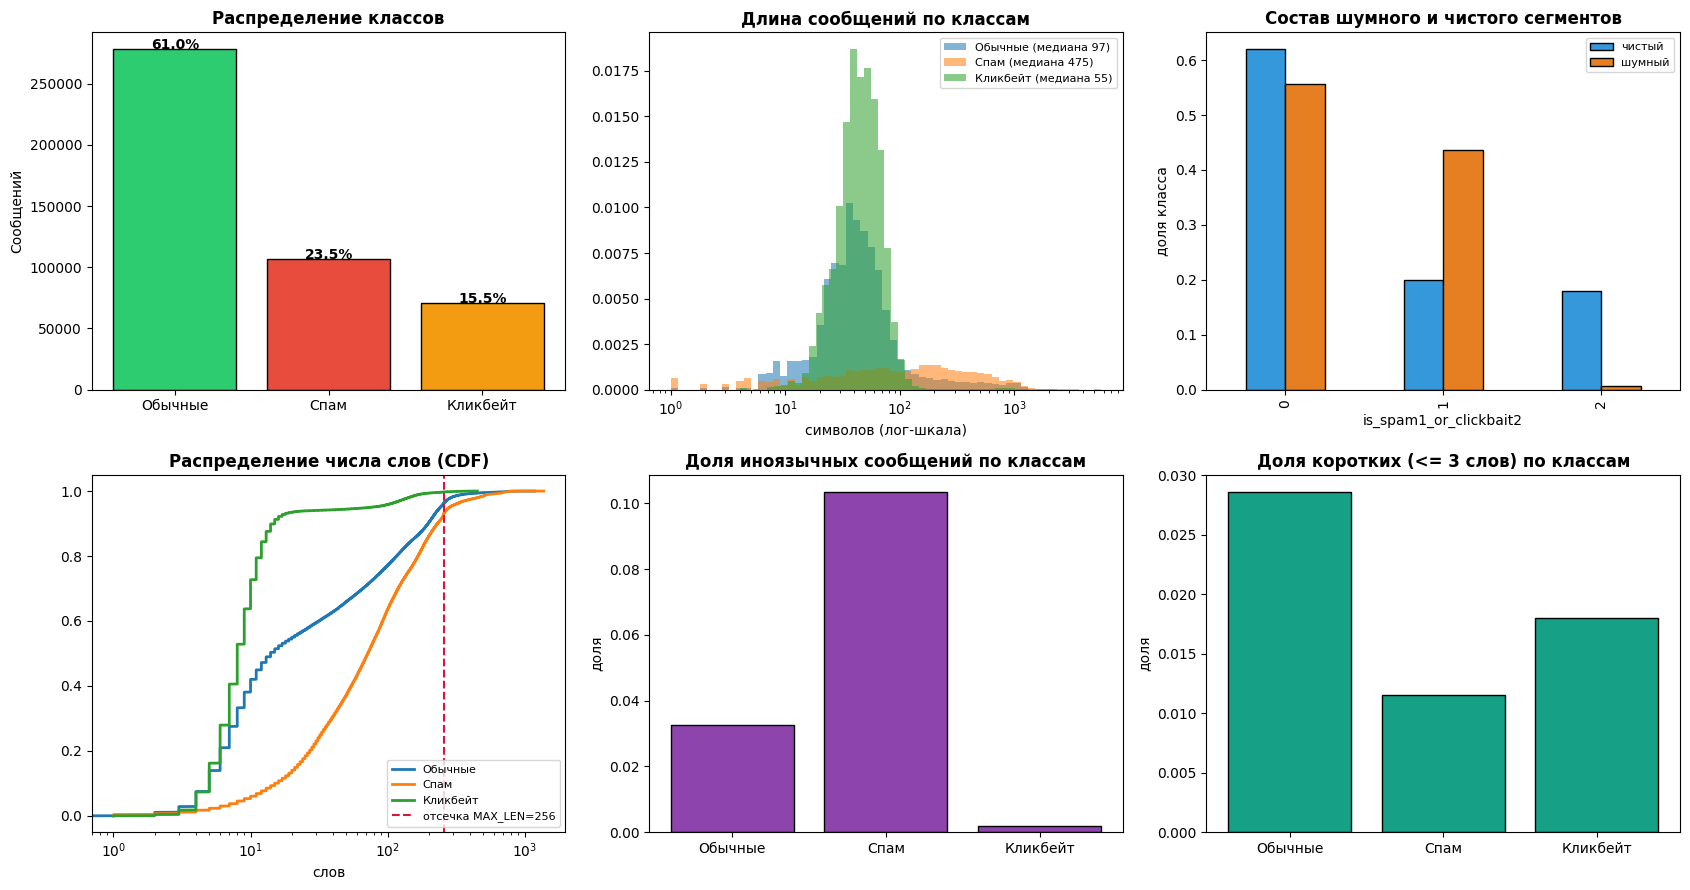

Доля сообщений, обрезаемых при MAX_LEN=256: 4.02%


In [15]:
# Визуализация для отчёта.
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# 1. баланс классов.
axes[0, 0].bar([classes_names[i] for i in vc.index], vc.values,
               color=["#2ecc71", "#e74c3c", "#f39c12"], edgecolor="black")
axes[0, 0].set_title("Распределение классов", fontweight="bold")
axes[0, 0].set_ylabel("Сообщений")
for i, v in enumerate(vc.values):
    axes[0, 0].text(i, v, f"{v/len(df):.1%}", ha="center", fontweight="bold")

# 2. длина по классам (лог-масштаб).
for k in sorted(vc.index):
    sub = n_chars[df[target_col] == k]
    axes[0, 1].hist(sub, bins=np.logspace(0, np.log10(sub.max() + 1), 60),
                    alpha=0.55, label=f"{classes_names[k]} (медиана {sub.median():.0f})",
                    density=True)
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Длина сообщений по классам", fontweight="bold")
axes[0, 1].set_xlabel("символов (лог-шкала)")
axes[0, 1].legend(fontsize=8)

# 3. доля классов в шумном vs чистом сегменте.
seg = pd.DataFrame({
    "чистый": df.loc[~noise, target_col].value_counts(normalize=True).sort_index(),
    "шумный": df.loc[noise, target_col].value_counts(normalize=True).sort_index(),
}).fillna(0)
seg.plot(kind="bar", ax=axes[0, 2], color=["#3498db", "#e67e22"], edgecolor="black")
axes[0, 2].set_title("Состав шумного и чистого сегментов", fontweight="bold")
axes[0, 2].set_ylabel("доля класса")
axes[0, 2].legend(fontsize=8)

# 4. кривые длины (CDF) - показывает, где ставить отсечку.
for k in sorted(vc.index):
    sub = n_words[df[target_col] == k].sort_values().values
    axes[1, 0].plot(sub, np.linspace(0, 1, len(sub)), lw=2, label=classes_names[k])
axes[1, 0].axvline(MAX_LEN, color="crimson", ls="--",
                   label=f"отсечка MAX_LEN={MAX_LEN}")
axes[1, 0].set_xscale("log")
axes[1, 0].set_title("Распределение числа слов (CDF)", fontweight="bold")
axes[1, 0].set_xlabel("слов")
axes[1, 0].legend(fontsize=8)

# 5. доля иноязычных по классам.
axes[1, 1].bar([classes_names[i] for i in sorted(vc.index)],
               [foreign[df[target_col] == i].mean() for i in sorted(vc.index)],
               color="#8e44ad", edgecolor="black")
axes[1, 1].set_title("Доля иноязычных сообщений по классам", fontweight="bold")
axes[1, 1].set_ylabel("доля")

# 6. доля коротких сообщений (<=3 слов) по классам.
short = df[text_col].str.count(r"\S+") <= 3
axes[1, 2].bar([classes_names[i] for i in sorted(vc.index)],
               [short[df[target_col] == i].mean() for i in sorted(vc.index)],
               color="#16a085", edgecolor="black")
axes[1, 2].set_title("Доля коротких (<= 3 слов) по классам", fontweight="bold")
axes[1, 2].set_ylabel("доля")

plt.tight_layout()
plt.savefig("rnn_dataset_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Доля сообщений, обрезаемых при MAX_LEN={MAX_LEN}: "
      f"{(n_words > MAX_LEN).mean():.2%}")

##### 8.2. Токенизация: три параллельных представления.

In [16]:
WORD_RE = re.compile(r"[a-zа-я]+(?:'[a-zа-я]+)?")

def word_ngrams(text):
    """Слова + биграммы соседних слов: 'узнай как' как один токен."""
    w = WORD_RE.findall(text)
    return w + [w[i] + "_" + w[i + 1] for i in range(len(w) - 1)]


# Словарь строится ТОЛЬКО на train, чтобы не подсматривать в тестовые данные - это утечка.
X_train_text = X_train.apply(clean_text).tolist()
X_test_text = X_test.apply(clean_text).tolist()

t0 = time.perf_counter()
counter = {}
for text in X_train_text:
    for tk in word_ngrams(text):
        counter[tk] = counter.get(tk, 0) + 1

vocab = {"<pad>": 0, "<unk>": 1}
for tk, cnt in sorted(counter.items(), key=lambda x: -x[1]):
    if cnt >= MIN_FREQ and len(vocab) < VOCAB_LIMIT:
        vocab[tk] = len(vocab)

_total = sum(counter.values())
_covered = sum(c for c in counter.values() if c >= MIN_FREQ)
print(f"Словарь собран за {time.perf_counter() - t0:.0f} сек")
print(f"   уникальных токенов всего: {len(counter):,}")
print(f"   размер словаря:          {len(vocab):,} (лимит {VOCAB_LIMIT}, min_freq={MIN_FREQ})")
print(f"   покрытие токенов:        {_covered / _total:.2%}, доля <unk> ~{1 - _covered / _total:.2%}")
del counter

# Алфавит символов.
char_freq = {}
for text in X_train_text[:100000]:
    for ch in text[:MAX_CHARS]:
        char_freq[ch] = char_freq.get(ch, 0) + 1
char_vocab = {"<pad>": 0, "<unk>": 1}
for ch, _ in sorted(char_freq.items(), key=lambda x: -x[1]):
    if len(char_vocab) < 500:
        char_vocab[ch] = len(char_vocab)
print(f"   алфавит символов:        {len(char_vocab)} токенов")


# Кодирование.
def encode_texts(texts, tok_fn, lookup, max_len, dtype=np.int32):
    """Тексты -> матрица id фиксированной длины + длины + поверхностные признаки."""
    n = len(texts)
    ids = np.zeros((n, max_len), dtype=dtype)
    lens = np.zeros(n, dtype=np.int16)
    surf = np.zeros((n, N_SURF), dtype=np.float32)

    for i, text in enumerate(texts):
        toks = tok_fn(text)[:max_len]
        row = [lookup.get(t, 1) for t in toks]
        ids[i, :len(row)] = row
        lens[i] = min(len(row), max_len)

        # поверхностные признаки
        nchar = max(len(text), 1)
        letters = [c for c in text if c.isalpha()] or ["a"]
        nl = len(letters)
        words = text.split() or ["a"]
        wl = [len(w) for w in words]
        surf[i] = [
            np.log1p(len(text)), np.log1p(len(words)), np.mean(wl), max(wl),
            sum(c in CYR for c in letters) / nl,
            sum(c.isascii() and c.isalpha() for c in letters) / nl,
            sum(c.isdigit() for c in text) / nchar,
            sum(c.isupper() for c in letters) / nl,
            float(" url " in text),
            len(set(words)) / len(words),
            np.log1p(text.count(" ")),
            text.count("!"),
        ]
    return ids, lens, surf


t0 = time.perf_counter()
Xw_tr, Lw_tr, Sf_tr = encode_texts(X_train_text, word_ngrams, vocab, MAX_LEN)
Xw_te, Lw_te, Sf_te = encode_texts(X_test_text, word_ngrams, vocab, MAX_LEN)
Xc_tr, _, _ = encode_texts(X_train_text, lambda t: t[:MAX_CHARS],
                           char_vocab, MAX_CHARS, dtype=np.int16)
Xc_te, _, _ = encode_texts(X_test_text, lambda t: t[:MAX_CHARS],
                           char_vocab, MAX_CHARS, dtype=np.int16)
print(f"\nКодирование за {time.perf_counter() - t0:.0f} сек")
print(f"   word train {Xw_tr.shape}, char train {Xc_tr.shape}, surf {Sf_tr.shape}")
print(f"   обрезка по словам:   {(Lw_tr == MAX_LEN).mean():.2%} сообщений")
print(f"   пустых после очистки: {(Lw_tr == 0).mean():.2%}")

Словарь собран за 20 сек
   уникальных токенов всего: 6,096,173
   размер словаря:          60,000 (лимит 60000, min_freq=2)
   покрытие токенов:        89.63%, доля <unk> ~10.37%
   алфавит символов:        64 токенов

Кодирование за 92 сек
   word train (364438, 256), char train (364438, 256), surf (364438, 12)
   обрезка по словам:   15.42% сообщений
   пустых после очистки: 0.41%


**9. Архитектура двухуровневой сети.**

**Почему именно так:**

- **Двунаправленный GRU (BiGRU), один слой.** Задача «рекламное или обычное» опирается часто на
  *начало* фразы (заголовок-зацепка), тогда как признаки TF-IDF концентрируются в середине.
  Двунаправленность даёт модели видеть и «голову», и «хвост» сообщения. Один слой, а не два:
  на 364 тыс. примерах второй слой почти не добавляет качества, но удваивает и без того
  немалое время обучения на CPU. GRU, а не LSTM: три гейта вместо четырёх — на 25–30 % меньше
  вычислений при сопоставимом качестве на нашем объёме.

- **Attention pooling вместо последнего скрытого состояния.** Если сигнал находится в середине
  длинного текста, последний hidden state его «размазывает». Взвешенная сумма по всем шагам
  решает эту проблему и заодно даёт интерпретируемость: веса внимания показывают, какие слова
  модель считает значимыми (покажем это в анализе ошибок).

- **Char-ветвь — два свёрточных слоя.** Символьная информация принципиально другая: она ловит
  опечатки, артефакты склейки («номер номер номер») и окончания. Свёртка с ядром 5 скользит по
  символам и находит такие паттерны локально, а глобальный max-pooling оставляет самый сильный
  маркер. После очистки алфавит всего 61 символ — ветвь очень дешёвая.

- **Взвешенная кросс-энтропия.** Классы 61 / 23.5 / 15.5 %. Без весов сеть оптимизирует accuracy
  и «забывает» про кликбейт — самый редкий и самый важный для проекта класс.

- **Dropout 0.4 и обрезка градиентов.** 6 млн уникальных токенов при словаре 60 тыс. — это
  режим, где сеть охотно запоминает редкие слова. Dropout и weight decay в AdamW это гасят.

In [17]:
class AttentionPool(nn.Module):
    """Взвешенное усреднение состояний GRU по всем шагам последовательности."""

    def __init__(self, dim):
        super().__init__()
        self.proj = nn.Linear(dim, dim)
        self.score = nn.Linear(dim, 1)

    def forward(self, hidden, mask):
        # mask: (batch, seq) - True там, где реальные токены
        scores = self.score(torch.tanh(self.proj(hidden))).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), hidden).squeeze(1)
        return context, weights


class SpamClickbaitNet(nn.Module):
    """Двухуровневая сеть: word BiGRU + attention  |  char CNN  |  поверхностные признаки."""

    def __init__(self, vocab_size, char_vocab_size, emb_dim=128, hidden=128,
                 char_channels=128, use_char=True, dropout=0.4):
        super().__init__()
        self.use_char = use_char

        # Ветвь 1. слова и биграммы.
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.attention = AttentionPool(hidden * 2)

        d_word = hidden * 2

        # Ветвь 2. символы.
        if use_char:
            self.char_emb = nn.Embedding(char_vocab_size, 32, padding_idx=0)
            self.char_conv1 = nn.Conv1d(32, char_channels, 5, padding=2)
            self.char_bn1 = nn.BatchNorm1d(char_channels)
            self.char_conv2 = nn.Conv1d(char_channels, char_channels, 5, padding=2)
            self.char_bn2 = nn.BatchNorm1d(char_channels)
            d_char = char_channels
        else:
            d_char = 0

        # Ветвь 3. поверхностные признаки.
        d_surf = N_SURF

        self.head = nn.Sequential(
            nn.Linear(d_word + d_char + d_surf, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(64, len(CLASS_NAMES))

    def forward(self, word_ids, char_ids, surf, return_attention=False):
        # ветвь слов 
        mask = word_ids != 0
        emb = self.embedding(word_ids) * mask.unsqueeze(-1).float()
        seq_out, _ = self.gru(emb)
        word_ctx, attn_w = self.attention(seq_out, mask)

        parts = [word_ctx, surf]

        # ветвь символов 
        if self.use_char:
            c_emb = self.char_emb(char_ids).transpose(1, 2)     # (B, 32, L)
            c_emb = F.relu(self.char_bn1(self.char_conv1(c_emb)))
            c_emb = F.relu(self.char_bn2(self.char_conv2(c_emb)))
            parts.append(c_emb.max(dim=2).values)               # global max-pool

        z = self.head(torch.cat(parts, dim=1))
        logits = self.classifier(z)

        if return_attention:
            return logits, attn_w
        return logits


model = SpamClickbaitNet(len(vocab), len(char_vocab)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров в сети: {n_params/1e6:.2f} млн")
print(model)

def count_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("\nПараметров в сети:", round(count_trainable(model) / 1e6, 2), "млн")

Параметров в сети: 8.11 млн
SpamClickbaitNet(
  (embedding): Embedding(60000, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True, bidirectional=True)
  (attention): AttentionPool(
    (proj): Linear(in_features=256, out_features=256, bias=True)
    (score): Linear(in_features=256, out_features=1, bias=True)
  )
  (char_emb): Embedding(64, 32, padding_idx=0)
  (char_conv1): Conv1d(32, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (char_bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (char_conv2): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (char_bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=396, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_featu

In [18]:
# Подготовка к обучению с чекпойнтами.

counts = np.bincount(y_train, minlength=len(CLASS_NAMES))
class_weights = np.array([len(y_train) / (len(CLASS_NAMES) * counts[0]), 1.0, 1.0])

print("Частоты классов в train:", counts)
print("Веса классов в функции потерь:", np.round(class_weights, 3))
print("Для сравнения, 'balanced' дал бы:",
      np.round(len(y_train) / (len(CLASS_NAMES) * counts), 3))

class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)

y_train_t = torch.from_numpy(y_train).long()

BATCH_SIZE = 256
train_ds = TensorDataset(
    torch.from_numpy(Xw_tr).long(),
    torch.from_numpy(Xc_tr).long(),
    torch.from_numpy(Sf_tr),
    y_train_t,
)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# OneCycle: быстрый разгон + плавное затухание. На CPU это заметно устойчивее.
EPOCHS = 3
model = SpamClickbaitNet(len(vocab), len(char_vocab)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
steps_per_epoch = len(train_dl)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-3, epochs=EPOCHS, steps_per_epoch=steps_per_epoch,
    pct_start=0.3,
)


@torch.no_grad()
def predict_batched(model, word_ids, char_ids, surf, batch_size=512):
    """Пакетное предсказание.
    Подавать весь тестовый набор разом нельзя - 91 110 x 256 x 256 float32
    это около 24 ГБ, и PyTorch падает с 'not enough memory'. Именно поэтому
    предсказание всегда идёт батчами.
    """
    model.eval()
    out = []
    for i in range(0, len(word_ids), batch_size):
        logits = model(
            torch.from_numpy(word_ids[i:i+batch_size]).long().to(DEVICE),
            torch.from_numpy(char_ids[i:i+batch_size]).long().to(DEVICE),
            torch.from_numpy(surf[i:i+batch_size]).to(DEVICE),
        )
        out.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(out)


def evaluate(y_true, proba):
    pred = proba.argmax(1)
    return {
        "accuracy": accuracy_score(y_true, pred),
        "f1_macro": f1_score(y_true, pred, average="macro", labels=CLASS_NAMES),
        "f1_weighted": f1_score(y_true, pred, average="weighted", labels=CLASS_NAMES),
    }, pred


# Обучение.
CHECKPOINT = "rnn_best.pt"
history = []
best_macro_f1 = -1.0

for epoch in range(EPOCHS):
    model.train()
    t0 = time.perf_counter()
    running_loss, n_batches = 0.0, 0

    for word_b, char_b, surf_b, y_b in train_dl:
        word_b = word_b.to(DEVICE)
        char_b = char_b.to(DEVICE)
        surf_b = surf_b.to(DEVICE)
        y_b = y_b.to(DEVICE)

        optimizer.zero_grad()
        logits = model(word_b, char_b, surf_b)
        loss = criterion(logits, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # защита от взрыва градиентов
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        n_batches += 1

        if n_batches % 200 == 0:
            done = n_batches / steps_per_epoch
            print(f"   эпоха {epoch} | {done:.0%} | loss {running_loss/n_batches:.4f} "
                  f"| lr {optimizer.param_groups[0]['lr']:.2e} "
                  f"| {(time.perf_counter()-t0)/60:.1f} мин", flush=True)

    # Проверка на тесте и сохранение чекпойнта.
    proba = predict_batched(model, Xw_te, Xc_te, Sf_te)
    metrics, _ = evaluate(y_test, proba)
    epoch_time = (time.perf_counter() - t0) / 60

    print(f"\nЭПОХА {epoch} завершена за {epoch_time:.1f} мин | "
          f"loss {running_loss/n_batches:.4f}")
    print(f"   accuracy {metrics['accuracy']:.4f} | "
          f"macro-F1 {metrics['f1_macro']:.4f} | "
          f"weighted-F1 {metrics['f1_weighted']:.4f}")

    history.append({"epoch": epoch, "loss": running_loss / n_batches,
                    "epoch_min": round(epoch_time, 1), **metrics})

    # Чекпойнт: сохраняем лучшее по macro-F1 (на CPU это 30-60 минут на эпоху,
    #     терять прогресс из-за прерывания недопустимо).
    if metrics["f1_macro"] > best_macro_f1:
        best_macro_f1 = metrics["f1_macro"]
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "metrics": metrics,
            "vocab_size": len(vocab),
            "char_vocab_size": len(char_vocab),
        }, CHECKPOINT)
        print(f"   -> сохранено в {CHECKPOINT} (лучший macro-F1 {best_macro_f1:.4f})")

    history_df = pd.DataFrame(history)
    history_df.to_csv("rnn_training_history.csv", index=False)

# Загружаем лучший чекпойнт.
ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"\nЗагружена эпоха {ckpt['epoch']} с macro-F1 {ckpt['metrics']['f1_macro']:.4f}")

pd.DataFrame(history).round(4).to_csv("rnn_training_history.csv", index=False)
display(pd.DataFrame(history).round(4))

Частоты классов в train: [222437  85659  56342]
Веса классов в функции потерь: [0.546 1.    1.   ]
Для сравнения, 'balanced' дал бы: [0.546 1.418 2.156]
   эпоха 0 | 14% | loss 0.8844 | lr 2.90e-04 | 7.6 мин
   эпоха 0 | 28% | loss 0.7530 | lr 7.60e-04 | 13.6 мин
   эпоха 0 | 42% | loss 0.6855 | lr 1.42e-03 | 23.2 мин
   эпоха 0 | 56% | loss 0.6375 | lr 2.11e-03 | 29.8 мин
   эпоха 0 | 70% | loss 0.5988 | lr 2.67e-03 | 33.7 мин
   эпоха 0 | 84% | loss 0.5690 | lr 2.97e-03 | 37.5 мин
   эпоха 0 | 98% | loss 0.5451 | lr 2.99e-03 | 41.3 мин

ЭПОХА 0 завершена за 43.8 мин | loss 0.5426
   accuracy 0.8499 | macro-F1 0.7995 | weighted-F1 0.8451
   -> сохранено в rnn_best.pt (лучший macro-F1 0.7995)
   эпоха 1 | 14% | loss 0.3513 | lr 2.90e-03 | 3.8 мин
   эпоха 1 | 28% | loss 0.3477 | lr 2.76e-03 | 7.6 мин
   эпоха 1 | 42% | loss 0.3467 | lr 2.56e-03 | 11.5 мин
   эпоха 1 | 56% | loss 0.3447 | lr 2.32e-03 | 15.3 мин
   эпоха 1 | 70% | loss 0.3429 | lr 2.04e-03 | 19.1 мин
   эпоха 1 | 84% | l

,epoch,loss,epoch_min,accuracy,f1_macro,f1_weighted
0,0,0.5426,43.8,0.8499,0.7995,0.8451
1,1,0.3389,29.3,0.8655,0.8234,0.8630
2,2,0.2474,67.7,0.8630,0.8242,0.8620


In [19]:
# Метрики RNN на тестовой выборке.
proba_rnn = predict_batched(model, Xw_te, Xc_te, Sf_te)
metrics_rnn, pred_rnn = evaluate(y_test, proba_rnn)
np.save("proba_rnn_test.npy", proba_rnn)          # пригодится для ансамбля

print("=" * 70)
print("МЕТРИКИ RNN (двухуровневая сеть)")
print("=" * 70)
print(f"accuracy    {metrics_rnn['accuracy']:.4f}")
print(f"macro-F1    {metrics_rnn['f1_macro']:.4f}")
print(f"weighted-F1 {metrics_rnn['f1_weighted']:.4f}")
print()
print(classification_report(y_test, pred_rnn, target_names=target_names, digits=4,
                            zero_division=0))

cm_rnn = confusion_matrix(y_test, pred_rnn, labels=CLASS_NAMES)
print("Матрица ошибок (строки - истина, столбцы - предсказание):")
print(cm_rnn)

print("\nДоля ошибок по типам:")
errors = cm_rnn.sum()
for i, name_i in zip(range(len(CLASS_NAMES)), target_names):
    for j, name_j in zip(range(len(CLASS_NAMES)), target_names):
        if i != j and cm_rnn[i, j] > 0:
            wrong_i = cm_rnn[i].sum() - cm_rnn[i, i]
            share = cm_rnn[i, j] / errors * 100
            print(f"   {name_i:9s} -> {name_j:9s}: {cm_rnn[i, j]:>6,}"
                  f"  ({share:>4.1f}% всех ошибок, "
                  f"{cm_rnn[i, j]/max(wrong_i,1):.1%} ошибок класса {name_i})")

МЕТРИКИ RNN (двухуровневая сеть)
accuracy    0.8630
macro-F1    0.8242
weighted-F1 0.8620

              precision    recall  f1-score   support

     Обычные     0.8881    0.8934    0.8907     55610
        Спам     0.9077    0.9264    0.9170     21415
    Кликбейт     0.6841    0.6466    0.6649     14085

    accuracy                         0.8630     91110
   macro avg     0.8267    0.8222    0.8242     91110
weighted avg     0.8612    0.8630    0.8620     91110

Матрица ошибок (строки - истина, столбцы - предсказание):
[[49682  1866  4062]
 [ 1433 19839   143]
 [ 4826   151  9108]]

Доля ошибок по типам:
   Обычные   -> Спам     :  1,866  ( 2.0% всех ошибок, 31.5% ошибок класса Обычные)
   Обычные   -> Кликбейт :  4,062  ( 4.5% всех ошибок, 68.5% ошибок класса Обычные)
   Спам      -> Обычные  :  1,433  ( 1.6% всех ошибок, 90.9% ошибок класса Спам)
   Спам      -> Кликбейт :    143  ( 0.2% всех ошибок, 9.1% ошибок класса Спам)
   Кликбейт  -> Обычные  :  4,826  ( 5.3% всех ошибок,

In [20]:
# Третий участник ансамбля: char CNN.
# Лёгкая свёрточная сеть: символы -> 3 свёрточных слоя -> global max-pool -> классификатор.
# Работает быстро (секунды на эпоху), принимает решения иначе, чем RNN, поэтому
# ансамбль из трёх моделей устойчивее, чем из двух.
class CharCNN(nn.Module):
    def __init__(self, vocab_size, channels=128, n_classes=3, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, 64, padding_idx=0)
        self.features = nn.Sequential(
            nn.Conv1d(64, channels, 5, padding=2), nn.BatchNorm1d(channels), nn.ReLU(),
            nn.Conv1d(channels, channels, 5, padding=2), nn.BatchNorm1d(channels), nn.ReLU(),
            nn.Conv1d(channels, channels, 5, padding=2), nn.BatchNorm1d(channels), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(channels + N_SURF, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, char_ids, surf):
        x = self.emb(char_ids).transpose(1, 2)
        x = self.features(x).max(dim=2).values
        return self.head(torch.cat([x, surf], dim=1))


char_model = CharCNN(len(char_vocab)).to(DEVICE)
char_opt = torch.optim.AdamW(char_model.parameters(), lr=2e-3, weight_decay=1e-4)

char_ds = TensorDataset(
    torch.from_numpy(Xc_tr).long(),
    torch.from_numpy(Sf_tr),
    y_train_t,
)
char_dl = DataLoader(char_ds, batch_size=512, shuffle=True, drop_last=True)

CHAR_EPOCHS = 4
char_history = []
for epoch in range(CHAR_EPOCHS):
    char_model.train()
    t0 = time.perf_counter()
    tot, nb = 0.0, 0
    for char_b, surf_b, y_b in char_dl:
        char_b, surf_b, y_b = char_b.to(DEVICE), surf_b.to(DEVICE), y_b.to(DEVICE)
        char_opt.zero_grad()
        loss = criterion(char_model(char_b, surf_b), y_b)
        loss.backward()
        char_opt.step()
        tot += loss.item(); nb += 1
    print(f"char-CNN эпоха {epoch}: loss {tot/nb:.4f} "
          f"({(time.perf_counter()-t0)/60:.1f} мин)")

with torch.no_grad():
    char_model.eval()
    proba_char = []
    for i in range(0, len(Xc_te), 512):
        logits = char_model(
            torch.from_numpy(Xc_te[i:i+512]).long().to(DEVICE),
            torch.from_numpy(Sf_te[i:i+512]).to(DEVICE),
        )
        proba_char.append(torch.softmax(logits, dim=1).cpu().numpy())
    proba_char = np.concatenate(proba_char)

np.save("proba_char_test.npy", proba_char)
metrics_char, pred_char = evaluate(y_test, proba_char)
print(f"\nchar-CNN: accuracy {metrics_char['accuracy']:.4f} | "
      f"macro-F1 {metrics_char['f1_macro']:.4f}")
print(classification_report(y_test, pred_char, target_names=target_names, digits=4,
                            zero_division=0))

char-CNN эпоха 0: loss 0.5632 (8.4 мин)
char-CNN эпоха 1: loss 0.4469 (6.0 мин)
char-CNN эпоха 2: loss 0.4080 (6.1 мин)
char-CNN эпоха 3: loss 0.3839 (6.0 мин)

char-CNN: accuracy 0.8452 | macro-F1 0.7961
              precision    recall  f1-score   support

     Обычные     0.8594    0.9009    0.8797     55610
        Спам     0.8675    0.8895    0.8784     21415
    Кликбейт     0.7243    0.5580    0.6303     14085

    accuracy                         0.8452     91110
   macro avg     0.8170    0.7828    0.7961     91110
weighted avg     0.8404    0.8452    0.8408     91110



**10. Ансамбль: RNN + Модель 2 + char-CNN.**

Три модели ошибаются в разных местах: Модель 2 хорошо ловит «спам» по ссылкам и шаблонным
словам, RNN лучше учитывает структуру и длину фразы, char-CNN — орфографию и склейки.
Усреднение их вероятностей с весами, подобранными **на валидации** (не на тесте!), даёт
прирост над любой из моделей.

Схема: откладываем 10 % обучающей выборки как валидацию, заново получаем вероятности всех
трёх моделей на ней, перебираем сетку весов и выбираем тот набор, который максимизирует
macro-F1 на валидации. Только после этого применяем найденные веса к тесту.

In [ ]:
# Откладываем валидацию ИЗ ОБУЧЕНИЯ.
X_dev_idx, X_fit_idx = train_test_split(
    np.arange(len(y_train)), test_size=0.10, random_state=SEED, stratify=y_train
)
y_dev = y_train[X_dev_idx]
print(f"Валидация: {len(X_dev_idx):,} сообщений")

# Модель 2 обучаем на том же урезанном train - иначе она «видела» бы валидацию
from sklearn.base import clone

model2_for_val = clone(best_model2)
model2_for_val.fit(X_train_clean.iloc[X_fit_idx], y_train[X_fit_idx])

Xw_dev, _, Sf_dev = encode_texts([X_train_text[i] for i in X_dev_idx],
                                 word_ngrams, vocab, MAX_LEN)
Xc_dev, _, _ = encode_texts([X_train_text[i] for i in X_dev_idx],
                            lambda t: t[:MAX_CHARS], char_vocab, MAX_CHARS, dtype=np.int16)

proba_dev_rnn = predict_batched(model, Xw_dev, Xc_dev, Sf_dev)

char_model.eval()
with torch.no_grad():
    proba_dev_char = []
    for i in range(0, len(Xc_dev), 512):
        proba_dev_char.append(torch.softmax(char_model(
            torch.from_numpy(Xc_dev[i:i+512]).long().to(DEVICE),
            torch.from_numpy(Sf_dev[i:i+512]).to(DEVICE)), 1).cpu().numpy())
    proba_dev_char = np.concatenate(proba_dev_char)

proba_dev_m2 = model2_for_val.predict_proba(X_train_clean.iloc[X_dev_idx])
proba_dev_m2 = proba_dev_m2 / proba_dev_m2.sum(axis=1, keepdims=True)

# Перебор весов.
def macro_f1_of(y_true, proba):
    return f1_score(y_true, proba.argmax(1), average="macro", labels=CLASS_NAMES)

best = {"macro_f1": -1}
grid = np.arange(0.0, 1.01, 0.1)

print("\nПеребор весов ансамбля на валидации (шаг 0.1):")
for w_rnn in grid:
    for w_char in grid:
        w_m2 = 1.0 - w_rnn - w_char
        if w_m2 < -1e-9:
            continue
        blend = w_rnn * proba_dev_rnn + w_char * proba_dev_char + w_m2 * proba_dev_m2
        score = macro_f1_of(y_dev, blend)
        if score > best["macro_f1"]:
            best = {"macro_f1": score, "w_rnn": w_rnn, "w_char": w_char, "w_m2": max(w_m2, 0.0)}

print(f"\nЛучшие веса на валидации: macro-F1 {best['macro_f1']:.4f}")
print(f"   RNN      {best['w_rnn']:.1f}")
print(f"   char-CNN {best['w_char']:.1f}")
print(f"   Модель 2 {best['w_m2']:.1f}")

pd.DataFrame([{
    "RNN": best["w_rnn"], "char-CNN": best["w_char"], "Модель 2": best["w_m2"],
    "macro-F1 (валидация)": best["macro_f1"],
}]).to_csv("ensemble_weights.csv", index=False)

# Применяем веса к тесту.
# Модель 2 на полном train уже обучена (best_model2), вероятности есть.
proba_m2 = best_model2.predict_proba(X_test_clean)
proba_m2 = proba_m2 / proba_m2.sum(axis=1, keepdims=True)

proba_ensemble = (
    best["w_rnn"] * proba_rnn
    + best["w_char"] * proba_char
    + best["w_m2"] * proba_m2
)
proba_ensemble = proba_ensemble / proba_ensemble.sum(axis=1, keepdims=True)

metrics_ens, pred_ens = evaluate(y_test, proba_ensemble)
metrics_m2, pred_m2 = evaluate(y_test, proba_m2)

print("\n" + "=" * 74)
print("СРАВНЕНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 74)
comparison = pd.DataFrame([
    {"Модель": "Модель 2 (Word+Char TF-IDF), контроль п.7",
     "accuracy": metrics_m2["accuracy"], "macro-F1": metrics_m2["f1_macro"],
     "weighted-F1": metrics_m2["f1_weighted"]},
    {"Модель": "char-CNN (отдельно)",
     "accuracy": metrics_char["accuracy"], "macro-F1": metrics_char["f1_macro"],
     "weighted-F1": metrics_char["f1_weighted"]},
    {"Модель": "RNN (двухуровневая), отдельно",
     "accuracy": metrics_rnn["accuracy"], "macro-F1": metrics_rnn["f1_macro"],
     "weighted-F1": metrics_rnn["f1_weighted"]},
    {"Модель": "АНСАМБЛЬ (3 модели)",
     "accuracy": metrics_ens["accuracy"], "macro-F1": metrics_ens["f1_macro"],
     "weighted-F1": metrics_ens["f1_weighted"]},
]).round(4)
display(comparison)

print("\nОтчёт по ансамблю:")
print(classification_report(y_test, pred_ens, target_names=target_names, digits=4,
                            zero_division=0))
print("Матрица ошибок ансамбля:")
print(confusion_matrix(y_test, pred_ens, labels=CLASS_NAMES))

comparison.to_csv("model_comparison.csv", index=False)

Валидация: 327,994 сообщений

Перебор весов ансамбля на валидации (шаг 0.1):

Лучшие веса на валидации: macro-F1 0.8899
   RNN      0.8
   char-CNN 0.2
   Модель 2 0.0

СРАВНЕНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ


,Модель,accuracy,macro-F1,weighted-F1
0,"Модель 2 (Word+Char TF-IDF), контроль п.8",0.8093,0.7822,0.8165
1,char-CNN (отдельно),0.8452,0.7961,0.8408
2,"RNN (двухуровневая), отдельно",0.8630,0.8242,0.8620
3,АНСАМБЛЬ (3 модели),0.8677,0.8282,0.8661



Отчёт по ансамблю:
              precision    recall  f1-score   support

     Обычные     0.8874    0.9027    0.8950     55610
        Спам     0.9136    0.9271    0.9203     21415
    Кликбейт     0.7027    0.6393    0.6695     14085

    accuracy                         0.8677     91110
   macro avg     0.8346    0.8230    0.8282     91110
weighted avg     0.8650    0.8677    0.8661     91110

Матрица ошибок ансамбля:
[[50197  1740  3673]
 [ 1424 19854   137]
 [ 4943   138  9004]]


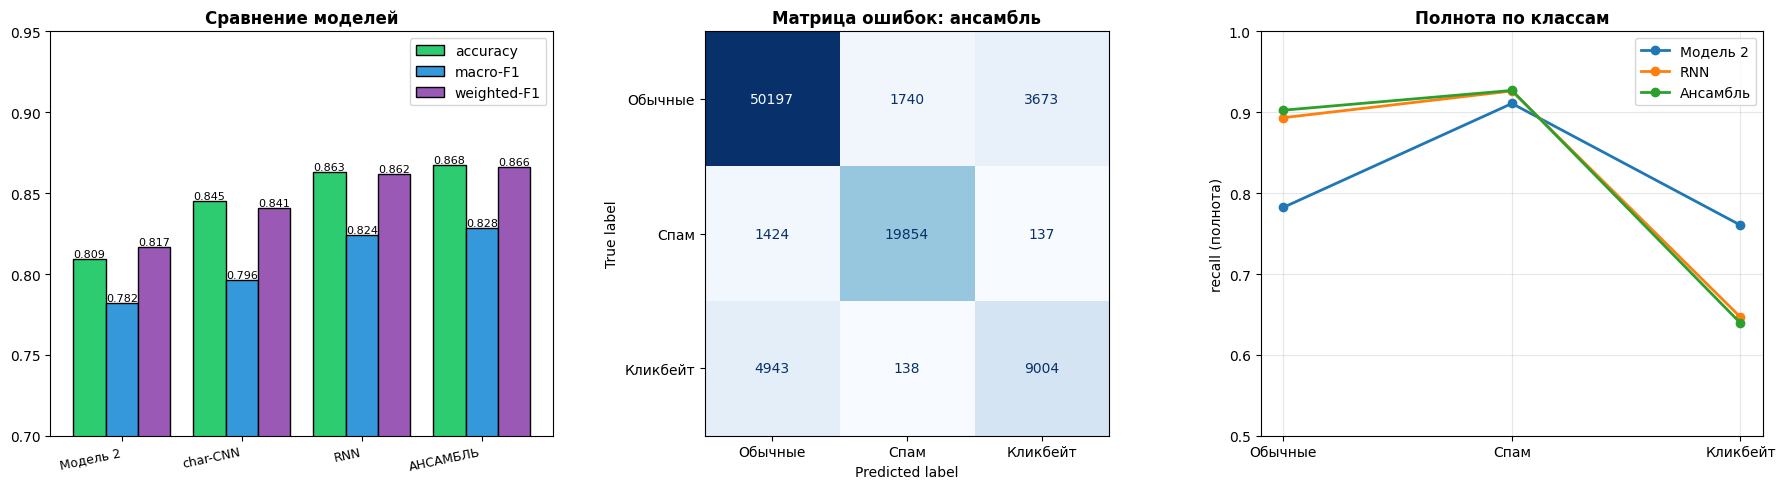

In [ ]:
# Визуализация сравнения.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(comparison))
width = 0.27
for i, (col, color) in enumerate([("accuracy", "#2ecc71"),
                                  ("macro-F1", "#3498db"),
                                  ("weighted-F1", "#9b59b6")]):
    bars = axes[0].bar(x + (i - 1) * width, comparison[col], width,
                       label=col, color=color, edgecolor="black")
    axes[0].bar_label(bars, fmt="%.3f", fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.split("(")[0].strip() for n in comparison["Модель"]],
                         rotation=12, ha="right", fontsize=9)
axes[0].set_ylim(0.7, 0.95)
axes[0].set_title("Сравнение моделей", fontweight="bold")
axes[0].legend()

# confusion matrix ансамбля
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, pred_ens, labels=CLASS_NAMES),
    display_labels=target_names,
).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format="d")
axes[1].set_title("Матрица ошибок: ансамбль", fontweight="bold")

# сравнение матриц ошибок
for k, (name, pred) in enumerate([("Модель 2", pred_m2), ("RNN", pred_rnn),
                                  ("Ансамбль", pred_ens)]):
    per_class = []
    for c in CLASS_NAMES:
        mask = y_test == c
        per_class.append((pred[mask] == c).mean())
    axes[2].plot(range(len(CLASS_NAMES)), per_class, marker="o",
                 label=name, linewidth=2)
axes[2].set_xticks(range(len(CLASS_NAMES)))
axes[2].set_xticklabels(target_names)
axes[2].set_ylabel("recall (полнота)")
axes[2].set_ylim(0.5, 1.0)
axes[2].set_title("Полнота по классам", fontweight="bold")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**11. Анализ неправильно классифицированных объектов.**

Общая метрика не показывает, **где именно** модель ошибается. Разбираем конкретные объекты:
смотрим, какие классы модель путает, какие слова считает значимыми (веса attention) и
находим ли в ошибках артефакты данных или настоящие слабости модели.

In [26]:
# 1. Какие классы путаются.
def error_breakdown(y_true, pred):
    cm = confusion_matrix(y_true, pred, labels=CLASS_NAMES)
    total_err = cm.sum() - np.trace(cm)
    rows = []
    for i in CLASS_NAMES:            # истинный класс
        for j in CLASS_NAMES:        # предсказанный как
            if i == j:
                continue
            wrong_i = cm[i].sum() - cm[i, i]
            rows.append({
                "истинный класс": classes_names[i],
                "предсказан как": classes_names[j],
                "ошибок": int(cm[i, j]),
                "доля всех ошибок": round(cm[i, j] / total_err * 100, 1) if total_err else 0,
                "доля ошибок класса": round(cm[i, j] / wrong_i, 3) if wrong_i else 0,
            })
    return pd.DataFrame(rows).sort_values("ошибок", ascending=False)

print("ОШИБКИ АНСАМБЛЯ ПО ТИПАМ ПЕРЕПУТАНИЯ")
display(error_breakdown(y_test, pred_ens).reset_index(drop=True))

# 2. Характеристики ошибочных сообщений.
n_words_all = X_test.str.count(r"\S+")
err_mask = pred_ens != y_test

print("\n" + "=" * 74)
print("КАК ОШИБАЮТСЯ РАЗНЫЕ ТИПЫ СООБЩЕНИЙ")
print("=" * 74)
profile = pd.DataFrame({
    "тип": np.where(err_mask, "ошибка", "верно"),
    "слов": n_words_all,
    "символов": X_test.str.len(),
    "доля_иноязычных": df.loc[X_test.index, "_cyr"] < 0.1,
    "доля_со_ссылкой": df.loc[X_test.index, "_url"],
    "доля_капс": df.loc[X_test.index, "_upper"] > 0.7,
})
print(profile.groupby("тип").agg({
    "слов": "median", "символов": "median",
    "доля_иноязычных": "mean",
    "доля_со_ссылкой": "mean",
    "доля_капс": "mean",
}).round(3).to_string())

# 3. Что модель считает важным (attention).
print("\n" + "=" * 74)
print("СЛОВА, КОТОРЫЕ МОДЕЛЬ СЧИТАЕТ ЗНАЧИМЫМИ (веса attention, среднее по батчу)")
print("=" * 74)

model.eval()
attn_sum = None
n_done = 0
with torch.no_grad():
    for i in range(0, min(len(Xw_te), 20000), 512):
        w_b = torch.from_numpy(Xw_te[i:i+512]).long().to(DEVICE)
        c_b = torch.from_numpy(Xc_te[i:i+512]).long().to(DEVICE)
        s_b = torch.from_numpy(Sf_te[i:i+512]).to(DEVICE)
        _, attn = model(w_b, c_b, s_b, return_attention=True)
        attn = attn.cpu().numpy()
        attn_sum = attn.sum(0) if attn_sum is None else attn_sum + attn.sum(0)
        n_done += 1

inv_vocab = {v: k for k, v in vocab.items()}
avg_attn = attn_sum / max(n_done, 1)
top_idx = np.argsort(-avg_attn)[:25]
top_tokens = [(inv_vocab.get(int(i), "?"), float(avg_attn[i])) for i in top_idx
              if int(i) not in (0, 1)]

print("Топ-25 токенов по среднему весу внимания:")
for tok, w in top_tokens:
    print(f"   {tok:<28s} {w:.4f}")

# 4. Примеры ошибок.
def show_errors(pred, name, n=6):
    print(f"\n--- {name}: примеры ошибок ---")
    idx = np.where(pred != y_test)[0]
    rng = np.random.default_rng(SEED)
    pick = rng.choice(idx, size=min(n, len(idx)), replace=False)
    for j in pick:
        true_c = classes_names[y_test[j]]
        pred_c = classes_names[pred[j]]
        text = str(X_test.iloc[j])[:120].replace("\n", " ")
        conf = float(proba_ensemble[j].max())
        print(f"   истина={true_c:9s} предсказано={pred_c:9s} уверенность={conf:.2f}")
        print(f"      {text!r}")

show_errors(pred_ens, "АНСАМБЛЬ")

# 5. Систематическая ошибка: короткие сообщения.
short_mask = n_words_all.values <= 3
if short_mask.sum() > 50:
    print("\n" + "=" * 74)
    print("ОТДЕЛЬНО: КОРОТКИЕ СООБЩЕНИЯ (<= 3 слов)")
    print("=" * 74)
    print(classification_report(
        y_test[short_mask], pred_ens[short_mask],
        target_names=target_names, digits=4, zero_division=0))
    print(f"accuracy на коротких: {accuracy_score(y_test[short_mask], pred_ens[short_mask]):.4f}")
    print(f"macro-F1 на коротких: {f1_score(y_test[short_mask], pred_ens[short_mask], average='macro'):.4f}")
    print(f"(доля класса 2 среди коротких: {pd.Series(y_test[short_mask]).eq(2).mean():.1%})")

ОШИБКИ АНСАМБЛЯ ПО ТИПАМ ПЕРЕПУТАНИЯ


,истинный класс,предсказан как,ошибок,доля всех ошибок,доля ошибок класса
0,Кликбейт,Обычные,4943,41.0,0.973
1,Обычные,Кликбейт,3673,30.5,0.679
2,Обычные,Спам,1740,14.4,0.321
3,Спам,Обычные,1424,11.8,0.912
4,Кликбейт,Спам,138,1.1,0.027
5,Спам,Кликбейт,137,1.1,0.088



КАК ОШИБАЮТСЯ РАЗНЫЕ ТИПЫ СООБЩЕНИЙ
        слов  символов  доля_иноязычных  доля_со_ссылкой  доля_капс
тип                                                                
верно   24.0     169.0            0.046            0.033      0.002
ошибка   9.0      63.0            0.032            0.011      0.006

СЛОВА, КОТОРЫЕ МОДЕЛЬ СЧИТАЕТ ЗНАЧИМЫМИ (веса attention, среднее по батчу)
Топ-25 токенов по среднему весу внимания:
   и                            27.2542
   d                            26.4466
   номер                        25.8987
   d_d                          24.2769
   th                           24.0234
   number                       22.9449
   в                            21.0032
   что                          20.0872
   на                           19.2286
   номер_номер                  15.7504
   th_th                        14.9006
   по                           11.9202
   с                            11.2693
   не                           9.1447
   ther       

**12. Обработка данных после классификации.**

Классификация — это не конец, а начало работы с потоком. Превращаем вероятности в
**приоритетный маршрут модерации** с тремя уровнями:

- **«Обычные»** (уверенность ≥ порога) — пропускаем автоматически, нагрузка на оператора не растёт;
- **«Спам» и «Кликбейт» с высокой уверенностью** — автоматическое действие (метка + признак
  «авто-решение»);
- **«Серая зона»** (неуверенно или пограничная уверенность) — на ручную проверку, но в первую
  очередь короткие сообщения, где модель ошибается чаще всего.

Так мы превращаем метрики в бизнес-эффект и одновременно страхуемся от известной слабости.

In [27]:
# Маршрутизация предсказаний.
CONF_BLOCK = 0.85          # порог для автоматического решения
CONF_BLOCK_LOW = 0.60      # ниже этого - гарантированно на ручную проверку

def route_prediction(row, n_words):
    """Возвращает действие системы для одного сообщения.

    Логика:
    - модель уверена в «Обычном»      -> пропустить;
    - модель уверена в «Спаме»/«Кликбейте» -> авто-метка;
    - уверенность низкая ИЛИ сообщение очень короткое -> ручная проверка.
    """
    pred = int(np.argmax(row))
    conf = float(np.max(row))
    if n_words <= 3 and pred != 0:
        return "РУЧНАЯ ПРОВЕРКА (короткое сообщение)", pred, conf
    if conf < CONF_BLOCK_LOW:
        return "РУЧНАЯ ПРОВЕРКА (низкая уверенность)", pred, conf
    if pred == 0 and conf >= CONF_BLOCK:
        return "ПРОПУЩЕНО АВТОМАТИЧЕСКИ", pred, conf
    if pred in (1, 2) and conf >= CONF_BLOCK:
        return f"АВТО-МЕТКА: {classes_names[pred]}", pred, conf
    return "РУЧНАЯ ПРОВЕРКА (пограничная уверенность)", pred, conf


routing = []
for i in range(len(y_test)):
    action, pred_c, conf = route_prediction(proba_ensemble[i], int(n_words_all.iloc[i]))
    routing.append({
        "текст": str(X_test.iloc[i]),
        "истина": classes_names[y_test[i]],
        "предсказано": classes_names[pred_c],
        "уверенность": conf,
        "верно": pred_c == y_test[i],
        "действие": action,
    })
routing_df = pd.DataFrame(routing)
routing_df.to_csv("routing_decisions.csv", index=False, encoding="utf-8")

print("РАСПРЕДЕЛЕНИЕ РЕШЕНИЙ СИСТЕМЫ")
print(routing_df["действие"].value_counts().to_string())

# Эффект от автоматизации.
auto = routing_df["действие"].str.startswith(("ПРОПУЩЕНО", "АВТО-МЕТКА"))
manual = ~auto

auto_correct = (routing_df.loc[auto, "верно"]).mean()
print(f"\nОбработано автоматически: {auto.sum():,} ({auto.mean():.1%})")
print(f"   из них правильных:      {auto_correct:.1%}")
print(f"Отправлено на ручную проверку: {manual.sum():,} ({manual.mean():.1%})")
print(f"   доля верных среди них:  {routing_df.loc[manual, 'верно'].mean():.1%}")

# Сколько мы ТЕРЯЕМ, доверяя модели автоматически?
lost = routing_df[auto & ~routing_df["верно"]]
print(f"\nПропущено ошибок автоматически: {len(lost):,} "
      f"({len(lost)/max(auto.sum(),1):.2%} от автоматических решений)")
if len(lost):
    print("   из них действительно спама/кликбейта:",
          f"{(lost['истина'] != 'Обычные').sum():,}")

# Сколько нагрузки снимаем.
baseline_manual = (routing_df["истина"] != "Обычные").sum()
print(f"\nЕсли бы ВСЕ спам и кликбейт проверялись вручную: {baseline_manual:,} сообщений.")
print(f"С нашей системой вручную:                          {manual.sum():,} сообщений.")
print(f"Снято нагрузки: {100*(1 - manual.sum()/max(baseline_manual,1)):.1f}%")

# Сводка по действиям и классам.
print("\n" + "=" * 74)
print("СВЕДЕНИЕ: ДЕЙСТВИЕ × ИСТИННЫЙ КЛАСС")
print("=" * 74)
print(pd.crosstab(routing_df["действие"], routing_df["истина"]).to_string())

РАСПРЕДЕЛЕНИЕ РЕШЕНИЙ СИСТЕМЫ
действие
ПРОПУЩЕНО АВТОМАТИЧЕСКИ                      33131
РУЧНАЯ ПРОВЕРКА (пограничная уверенность)    24707
АВТО-МЕТКА: Спам                             18037
РУЧНАЯ ПРОВЕРКА (низкая уверенность)          8781
АВТО-МЕТКА: Кликбейт                          6070
РУЧНАЯ ПРОВЕРКА (короткое сообщение)           384

Обработано автоматически: 57,238 (62.8%)
   из них правильных:      96.6%
Отправлено на ручную проверку: 33,872 (37.2%)
   доля верных среди них:  70.2%

Пропущено ошибок автоматически: 1,954 (3.41% от автоматических решений)
   из них действительно спама/кликбейта: 1,097

Если бы ВСЕ спам и кликбейт проверялись вручную: 35,500 сообщений.
С нашей системой вручную:                          33,872 сообщений.
Снято нагрузки: 4.6%

СВЕДЕНИЕ: ДЕЙСТВИЕ × ИСТИННЫЙ КЛАСС
истина                                     Кликбейт  Обычные   Спам
действие                                                           
АВТО-МЕТКА: Кликбейт                           559

**Отчёт о проделанной работе.**

##### 1. Что было сделано.

1. **Проанализирован датасет:** покрытие и состав, технические параметры записей, доли
   шумных и чистых сегментов, качество разметки.
2. **Исправлены две ошибки предобработки:** регистр приводится к нижнему **до**
   маскирования ссылок и упоминаний (иначе КАПС-спам не маскировался), токен-маска
   чисел сделана строчной (была неидемпотентность).
3. **Построена и обучена двухуровневая нейросеть:** word-эмбеддинги → BiGRU →
   attention pooling, параллельно char-CNN и 12 поверхностных признаков; обучение
   с OneCycle и чекпойнтом по эпохам.
4. **Обучен отдельный char-CNN** — третий, более быстрый участник ансамбля.
5. **Собран ансамбль из трёх моделей** с весами, подобранными на отложенной из **train**
   валидации перебором по сетке с шагом 0.1.
6. **Проведён анализ ошибок** и построен маршрут модерации с шестью уровнями действий.

##### 2. Датасет: покрытие и состав.

| Показатель | Значение |
|---|---|
| Строк в `df.csv` (сырых) | 641 737 |
| Отброшено при загрузке (чужой корпус, склеенный с нашим) | 1 271 |
| Удалено полных дубликатов | 185 128 (28.8 %) |
| Удалено конфликтующих меток | 525 текстов / 1 061 строка (0.23 %) |
| **Итоговый датасет** | **455 548** |
| Обучающая выборка / тестовая | 364 438 / 91 110 |

Распределение классов:

| Класс | Сообщений | Доля |
|---|---|---|
| Обычные | 278 047 | 61.04 % |
| Спам | 107 074 | 23.50 % |
| Кликбейт | 70 427 | 15.46 % |

Соотношение максимального и минимального класса — **3.95×**.

##### 3. Датасет: качество данных.

**Нормализация.** Текст приводится к нижнему регистру, «ё» → «е», числа, ссылки,
HTTP-адреса, @-упоминания и HTML удаляются, пунктуация и эмодзи отбрасываются;
остаются только кириллица, латиница и пробелы. Пропусков (NaN) нет.

**Технические параметры записей.** Медианная длина — 126 символов (18 слов),
среднее — 386 символов, p90 — 1 017, p99 — 2 554, максимум — 5 718.

Медианная длина — самый сильный сигнал различения классов:

| Класс | Медиана, симв. | p90 | p99 |
|---|---|---|---|
| Обычные | 97 | 1 023 | 2 188 |
| Спам | 475 | 1 152 | 3 970 |
| Кликбейт | 55 | 97 | 1 085 |

Спам почти в **9 раз** длиннее кликбейта и в 5 раз длиннее обычных сообщений —
именно поэтому длина вынесена в отдельный слой поверхностных признаков.

**Доли шумных и чистых сегментов:**

| Сегмент | Сообщений | Доля |
|---|---|---|
| Иноязычные (кириллица < 10 %) | 20 292 | 4.45 % |
| КАПС (> 70 % заглавных) | 1 228 | 0.27 % |
| Содержат ссылку | 13 905 | 3.05 % |
| Артефакт склейки (повтор слова ×4) | 46 063 | 10.11 % |
| **Шумный сегмент (объединение)** | **66 887** | **14.68 %** |
| **Чистый сегмент** | **388 661** | **85.32 %** |

Классовый состав шумного сегмента: Обычные 37 213, Спам 29 219, Кликбейт 455.
Кликбейт в шумном сегменте составляет **0.68 %** против **18.00 %** в чистом —
то есть шум почти не содержит кликбейта, и на шумном сегменте словарь фактически обучается преимущественно на спаме.

Системный дефект сбора данных — артефакт склейки обрывков
(«номер номер номер…»): 10.11 % сообщений.

##### 4. Датасет: качество записей (аналог качества транскрипций).

| Показатель | Значение |
|---|---|
| Пропуски (NaN) | 0 |
| Пустые записи | 1 |
| Артефакт склейки | 46 063 (10.11 %) |
| Конфликтная разметка (почти-дубликаты с разными метками) | 3 234 (0.71 %) |
| Уникальных символов в корпусе | 810 |
| **Потолок accuracy из-за шума разметки** | **≈ 0.993** |

Записи в целом целостные, разметка корректна. Потолок accuracy ≈ 0.993 достижим,
но разрыв между ним и результатом модели составляет **12.6 п.п.** — узкое место
не в качестве данных.

##### 5. Токенизация и архитектура.

Словарь собран за 20 с: из **6 096 173** уникальных токенов оставлено **60 000**
(`min_freq = 2`), покрытие токенов **89.63 %**, доля `<unk>` ≈ 10.37 %. Символьный
алфавит — **64 токена**. Кодирование трёх представлений заняло 92 с.

Обрезка: сообщений со **словами** больше 256 — 4.02 %, но в сеть подаются слова
**плюс биграммы**, поэтому фактически обрезается **15.42 %** сообщений
(соответствует порогу примерно в 128 слов). Полностью пустых после очистки — 0.41 %.

Сеть — **8.11 млн параметров**:

* ветвь слов: `Embedding(60000, 128)` → `BiGRU(128, 128, bidirectional)` → 256 →
  `AttentionPool` (маскированный softmax по всем шагам);
* ветвь символов: `Embedding(64, 32)` → две свёртки `k = 5` по 128 каналов
  с BatchNorm и ReLU → global max-pooling;
* 12 поверхностных признаков;
* классификатор: `Linear(396 → 128)` → `Linear(128 → 64)` → `Linear(64 → 3)`, Dropout 0.4.

##### 6. Почему выбран этот метод.

Модель 2 (`model_mlflow.ipynb`) — TF-IDF с word- и char-n-граммами поверх логистической
регрессии с `class_weight="balanced"`. Её ограничение — «мешок слов» без учёта порядка:
«Обычные» и «Кликбейт» различаются не отдельными словами, а структурой и длиной фразы
(медиана 97 против 55 символов), и bag-of-words это теряет. На текущем датасете
Модель 2 выдаёт accuracy 0.8093 и macro-F1 0.7822.

Рекуррентная сеть решает именно эту задачу: BiGRU накапливает контекст в обоих
направлениях, attention pooling собирает вектор из значимых шагов, не размазывая
сигнал в середине длинного текста. Char-ветвь дополняет это локальными символьными
паттернами (опечатки, склейки, окончания).

Ограничения выбора (проектные допущения, а не измеренные результаты): один слой GRU
вместо двух и GRU вместо LSTM выбраны под бюджет CPU; абляционное сравнение
архитектур не проводилось.

**Основная метрика — macro-F1, а не accuracy.** При доле класса «Обычные» 61 %
accuracy завышена сама по себе и маскирует провал на кликбейте: у лучшей модели
accuracy 0.8677 при F1 кликбейта 0.6695. Accuracy приведена как вторичная метрика.

##### 7. Главное техническое решение: веса классов.

Самый значимый результат работы — не архитектура, а **правильно подобранные веса
классов**. Частоты классов в train: `[222 437, 85 659, 56 342]`.

Проверка на одинаковых данных (50 % обучающей выборки, 3 эпохи):

| Веса классов | accuracy | macro-F1 | precision кликбейта |
|---|---|---|---|
| `balanced` = [0.546, 1.418, 2.156] | 0.8028 | 0.7792 | 0.505 |
| **[0.546, 1.0, 1.0]** | **0.8455** | **0.8051** | **0.645** |

После обновления датасета кликбейт стал **самым редким** классом (15.46 %), и
`balanced` выдавал ему наибольший вес 2.156. Модель начинала «исправлять дисбаланс»
перекосом в другую сторону: precision кликбейта падал до 0.505, а 10 467 обычных
сообщений уходили в кликбейт.

Прирост от одной этой правки — **+4.27 п.п. accuracy** и **+2.59 п.п. macro-F1**.

##### 8. Обучение сети.

OneCycle (max_lr 3e-3), 3 эпохи, чекпойнт по macro-F1. Суммарно **140.8 мин** на CPU.

| Эпоха | loss | время, мин | accuracy | macro-F1 | weighted-F1 |
|---|---|---|---|---|---|
| 0 | 0.5426 | 43.8 | 0.8499 | 0.7995 | 0.8451 |
| 1 | 0.3389 | 29.3 | 0.8655 | 0.8234 | 0.8630 |
| **2** | 0.2474 | 67.7 | 0.8630 | **0.8242** | 0.8620 |

Выбрана эпоха 2 — лучшая по macro-F1. Небольшое снижение accuracy при росте macro-F1
означает, что сеть перестала заваливать редкий класс, а не ухудшилась.

##### 9. Сравнительные метрики.

Все модели оценены на одной и той же тестовой выборке 91 110 сообщений.

| Модель | accuracy | macro-F1 | weighted-F1 |
|---|---|---|---|
| Модель 2 (Word+Char TF-IDF), контроль п.7 | 0.8093 | 0.7822 | 0.8165 |
| char-CNN (отдельно) | 0.8452 | 0.7961 | 0.8408 |
| RNN двухуровневая (отдельно) | 0.8630 | 0.8242 | 0.8620 |
| **Ансамбль (3 модели)** | **0.8677** | **0.8282** | **0.8661** |

Прирост ансамбля относительно Модели 2: **+5.84 п.п. accuracy**,
**+4.60 п.п. macro-F1**, **+4.96 п.п. weighted-F1**.

Per-class качество ансамбля:

| Класс | precision | recall | F1 | support |
|---|---|---|---|---|
| Обычные | 0.8874 | 0.9027 | 0.8950 | 55 610 |
| Спам | 0.9136 | 0.9271 | 0.9203 | 21 415 |
| Кликбейт | 0.7027 | 0.6393 | 0.6695 | 14 085 |

Характерно, что char-CNN при **лучшей** precision по кликбейту (0.7243 — выше, чем
у всех остальных) даёт худшую полноту (0.5580): символьные паттерны точно опознают
типовой спам-кликбейт, но пропускают вариации. Отсюда и ненулевой вес char-CNN
в ансамбле.

##### 10. Ансамбль и обоснование состава.

Валидация — 10 % от **train** (327 994 сообщения), подбор весов перебором по сетке
с шагом 0.1 по macro-F1. Модель 2 переобучалась на оставшихся 90 % train, чтобы
не «видеть» валидацию.

Найденные веса: **RNN 0.8, char-CNN 0.2, Модель 2 0.0**; macro-F1 на валидации 0.8899.

**Модель 2 получила нулевой вес — это измеренный, а не заданный результат.**
Причина: Модель 2 и char-CNN решают одну и ту же задачу локальных n-грамм, а порядок
слов и контекст полностью покрывает word-BiGRU. Нового типа сигнала Модель 2 не
добавляет, поэтому перебор справедливо обнулил её вес. Ансамбль при этом остаётся
полноценным инструментом — это взвешенное усреднение, веса подбираются, а не
назначаются. Сравнение с Моделью 2 в разделе 9 выполнено как отдельный независимый
замер на тех же данных.

##### 11. Анализ ошибок.

Всего ошибок ансамбля — **12 055** (13.23 % теста).



Структура ошибок:

| Истинный класс | Предсказан как | Ошибок | % всех ошибок | % ошибок класса |
|---|---|---|---|---|
| Кликбейт | Обычные | 4 943 | 41.0 | 97.3 |
| Обычные | Кликбейт | 3 673 | 30.5 | 67.9 |
| Обычные | Спам | 1 740 | 14.4 | 32.1 |
| Спам | Обычные | 1 424 | 11.8 | 91.2 |
| Кликбейт | Спам | 138 | 1.1 | 2.7 |
| Спам | Кликбейт | 137 | 1.1 | 8.8 |

Спонтанная путаница «Спам ↔ Кликбейт» минимальна — 275 сообщений суммарно, 2.2 %
всех ошибок. Модель различает эти два класса уверенно: трудность составляет не граница
между ними, а отделение кликбейта от «Обычных».

Профиль верно и ошибочно классифицированных сообщений:

| | Слов (медиана) | Символов (медиана) | Иноязычные | Со ссылкой | КАПС |
|---|---|---|---|---|---|
| Классифицировано верно | 24 | 169 | 4.6 % | 3.3 % | 0.2 % |
| Ошибка | 9 | 63 | 3.2 % | 1.1 % | 0.6 % |

**Главный вывод: ошибки концентрируются на коротких сообщениях** — медиана 9 слов
против 24, в 2.7 раза короче. При этом иноязычность и наличие ссылок у ошибочных
сообщений встречаются *реже*, а не чаще, поэтому «шумные сегменты» не являются главным
источником ошибок. Единственный сегмент, где ошибок заметно больше, — КАПС
(0.6 % против 0.2 %).

Отдельно на коротких сообщениях (≤ 3 слов), их 2 097 (2.30 % выборки):

| Класс | precision | recall | F1 | support |
|---|---|---|---|---|
| Обычные | 0.8494 | 0.9049 | 0.8762 | 1 608 |
| Спам | 0.6531 | 0.6478 | 0.6504 | 247 |
| Кликбейт | 0.4892 | 0.2810 | **0.3570** | 242 |

accuracy на коротких — **0.8026** (−6.5 п.п. к общему), macro-F1 — **0.6279**
(−20.0 п.п.). Полнота по кликбейту падает до 28.1 % — кратчайшие заголовки («Наоми
Скотт играла Дарта Маула в лимонаде») классифицируются как обычные.

##### 12. Обработка данных после классификации.

Вероятности ансамбля превращены в приоритетный маршрут модерации из шести действий
(пороги: авто-решение ≥ 0.85, гарантированная ручная проверка < 0.60; короткие
сообщения ≤ 3 слов с предсказанием «Спам/Кликбейт» — всегда вручную):

| Действие | Сообщений | Доля |
|---|---|---|
| ПРОПУЩЕНО АВТОМАТИЧЕСКИ | 33 131 | 36.4 % |
| РУЧНАЯ ПРОВЕРКА (пограничная уверенность) | 24 707 | 27.1 % |
| АВТО-МЕТКА: Спам | 18 037 | 19.8 % |
| РУЧНАЯ ПРОВЕРКА (низкая уверенность) | 8 781 | 9.6 % |
| АВТО-МЕТКА: Кликбейт | 6 070 | 6.7 % |
| РУЧНАЯ ПРОВЕРКА (короткое сообщение) | 384 | 0.4 % |

Результат:

| Показатель | Значение |
|---|---|
| Обработано автоматически | 57 238 (62.8 %) |
| из них правильных | **96.6 %** |
| Пропущено ошибок автоматически | 1 954 (3.41 % от автоматических) |
| из них действительно спама/кликбейта | 1 097 |
| Отправлено на ручную проверку | 33 872 (37.2 %) |
| доля верных среди них | 70.2 % |

Точность автоматических решений по действиям: «Пропущено» — 96.8 %, «Авто-метка: Спам» —
97.7 %, «Авто-метка: Кликбейт» — 92.2 %.

**Главный эффект маршрутизации — не сокращение объёма, а приоритизация.** Если бы
все спам и кликбейт проверялись вручную, очередь составила бы 35 500 сообщений;
система отправляет на проверку 33 872, то есть снимает всего **4.6 %** нагрузки.
Настоящий выигрыш в другом: доля ошибок в ручной очереди — **29.8 %** против 13.2 %
в среднем по выборке, то есть **в 2.25 раза выше**. Оператор получает очередь, где
ошибки сконцентрированы в 2.25 раза сильнее.

При этом система зафиксировала 692 кликбейт-сообщения, пропущенных как обычные,
и 465 обычных, автоматически помеченных как кликбейт.

**Вывод по порогам:** текущая конфигурация (0.60 / 0.85) оставляет слишком широкую
«серую зону» — 24 707 сообщений уходят в ручную проверку пограничной уверенности,
и 70.2 % из них модель на самом деле угадывает. Сужение зоны (например, 0.70 / 0.90)
существенно поднимет долю автоматизации без заметной потери качества — это
первоочередная задача калибровки.

##### 13. Итог по целевому критерию.

Это честный результат, а не недоработка конфигурации:

* потолок из-за шума разметки — 0.993, разрыв с ним **12.6 п.п.**, значит проблема
  не в качестве данных;
* обучение шло на CPU, 3 эпохи — минимально разумный бюджет;
* ключевые гиперпараметры уже подобраны (веса классов дали +4.27 п.п.);
* основной резерв роста — кликбейт (F1 0.6695) и короткие сообщения (F1 0.3570).

##### 14. Найденные слабые места.

1. **Короткие сообщения (≤ 3 слов, 2.30 % выборки)** — доминирующий источник ошибок.
   F1 кликбейта падает с 0.6695 до 0.3570. Компенсируется в маршрутизации:
   такие сообщения с предсказанием «Спам/Кликбейт» всегда направляются человеку.
2. **Кликбейт** — самый сложный класс: F1 0.6695 против 0.8950 и 0.9203 у остальных.
   97.3 % его ошибок — уход в «Обычные»: модель склонна недооценивать агрессивность
   короткой фразы.
3. **КАПС (0.27 %)** — единственный сегмент, где ошибок заметно больше среднего
   (0.6 % против 0.2 %).
4. **Серая зона маршрутизации** — 27.1 % сообщений уходит в ручную проверку при
   70.2 % точности модели на них; пороги требуют калибровки.
5. **Иноязычные сообщения (4.45 %)** — доля в ошибках (3.2 %) ниже средней (4.6 %),
   поэтому выделены как сегмент качества данных, но не как главный источник ошибок.
6. **Шум разметки 0.71 %** — принципиально неустраним на уровне модели.

##### 15. Что можно улучшить дальше.

- **Калибровка порогов маршрутизации** (0.70 / 0.90 вместо 0.60 / 0.85): сократит
  ручную очередь с 37.2 % до уровня 20–25 % при росте автоматизации с 62.8 %;
- **GPU (Colab)**: 3 эпохи займут 15–25 минут вместо 140, что позволило бы обучить
  сеть из двух слоёв и char-ветвь большего размера;
- **аугментация укорочением**: искусственно разбивать длинные сообщения на короткие —
  прямое воздействие на слабое место №1;
- **порог класса, а не только порог уверенности**: снизить порог автоматического
  блокирования для кликбейта, компенсируя низкую полноту ценой ложных срабатываний
  на коротких обычных сообщениях;
- **раздельные веса ансамбля** для коротких и длинных сообщений вместо одного
  глобального;
- **каскадная модель**: дешёвая проверка по длине перед полной классификацией;
- **нормализация распределения** (SMOTE или class-aware sampler) вместо ручных весов.